In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [88]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [89]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [90]:
df.shape

(5000, 13)

In [91]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(2)

In [93]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

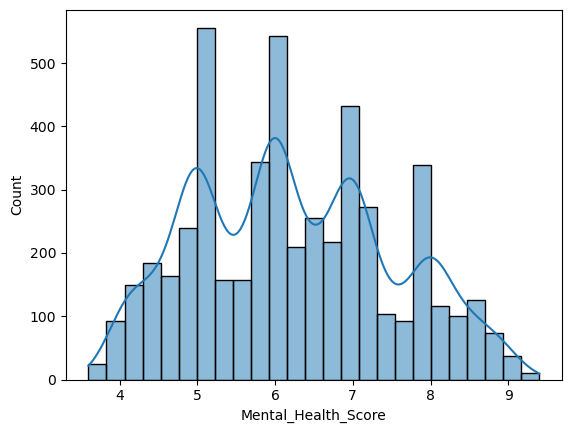

In [94]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

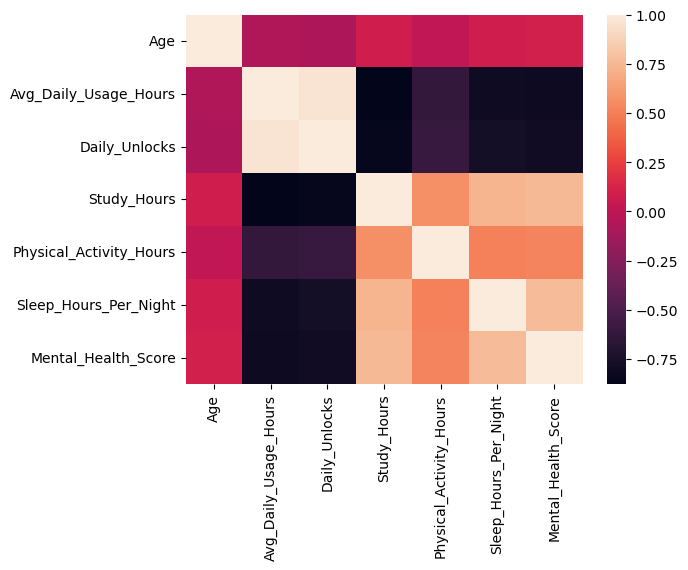

In [95]:
sns.heatmap(df.corr(numeric_only=True))

In [96]:
df['Stress_Level'].unique() 

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

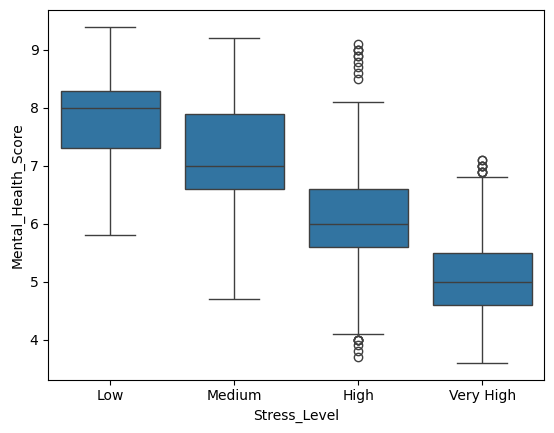

In [97]:
order=['Low','Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

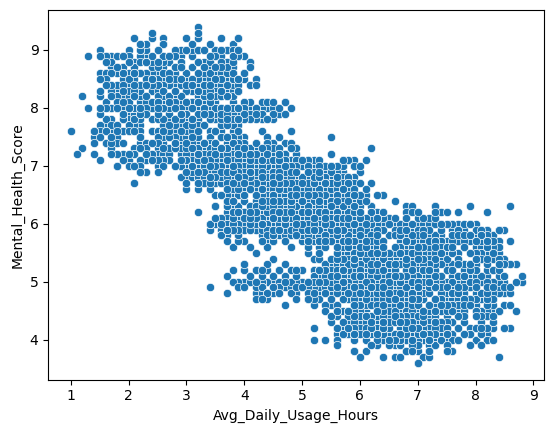

In [98]:
  sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

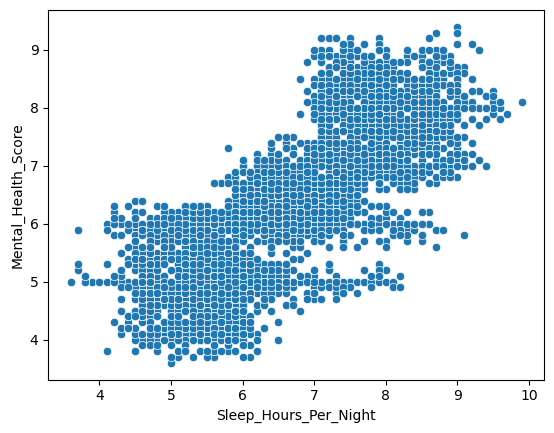

In [99]:
 sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

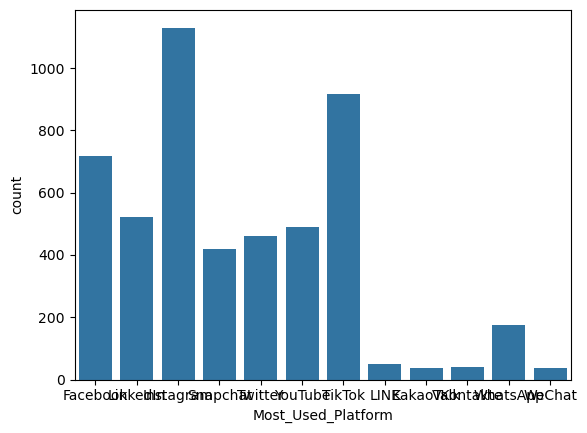

In [100]:
sns.countplot(x='Most_Used_Platform', data=df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

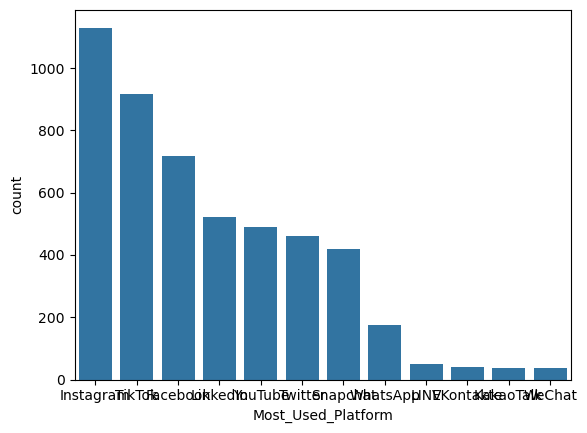

In [101]:
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

In [102]:
num_features=df.select_dtypes(include='number')
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [103]:
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q1+1.5*IQR
lower_bound

Age                        14.50
Avg_Daily_Usage_Hours       0.05
Daily_Unlocks              44.00
Study_Hours                -2.55
Physical_Activity_Hours    -0.05
Sleep_Hours_Per_Night       2.75
Mental_Health_Score         2.10
dtype: float64

In [104]:
upper_bound

Age                         23.50
Avg_Daily_Usage_Hours        7.55
Daily_Unlocks              236.00
Study_Hours                  5.55
Physical_Activity_Hours      2.65
Sleep_Hours_Per_Night        8.45
Mental_Health_Score          8.10
dtype: float64

In [105]:
outliers=(num_features<lower_bound)|(num_features>upper_bound)
outliers

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,False,False,False,False,False,False,False
1,False,False,False,True,False,True,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4995,False,False,False,True,False,False,False
4996,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False


In [106]:
df=df.drop_duplicates()
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [107]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [108]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [113]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [114]:
df['Grouped_country']=df['Country'].apply(group_countries)

In [125]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [126]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [122]:
skewed_col=['Study_Hours']
other_numeric_cols=['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_col=['Gender', 'Academic_Level', 'Most_Used_Platform','Purpose_Of_Use','Grouped_country']

feature_col=skewed_col+other_numeric_cols+ordinal_col+normal_col
x=df[feature_col]
y=df['Mental_Health_Score']

In [135]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
 
# 1. skewed features
skew_pipeline=Pipeline(steps=[('log_transform',FunctionTransformer(np.log1p)),
                              ('scale',StandardScaler())
                             ])
# 2. numeric features
plain_numeric_pipeline=Pipeline(steps=[('scale',StandardScaler())
                                      ])
# 3. ordinal features
ordinal_pipeline=Pipeline(steps=[('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
                                ])
# 4. nominal features  
nominal_pipeline=Pipeline(steps=[('encode',OneHotEncoder(handle_unknown='ignore'))
                                ])
preprocessor=ColumnTransformer(transformers=[
    ("Skewed_Pipeline",skew_pipeline,skewed_col),
    ("Plain_Numeric",plain_numeric_pipeline,other_numeric_cols),
    ("ordinal_Pipeline",ordinal_pipeline,ordinal_col),
    ("normal_pipeline",nominal_pipeline,normal_col)
])
preprocessor


,transformers,"[('Skewed_Pipeline', ...), ('Plain_Numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False


In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])
lr_pipeline.fit(x_train,y_train)       
lr_preds=lr_pipeline.predict(x_test)
lr_preds_train=lr_pipeline.predict(x_train)

lr_r2_testing=r2_score(y_test,lr_preds)
lr_r2_training=r2_score(y_train,lr_preds_train)

lr_mae=mean_absolute_error(y_test,lr_preds)

print(f"accuracy of training {lr_r2_training}")
print(f"accuracy of testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

accuracy of training 0.7236771199387539
accuracy of testing 0.739794461743302
MAE 0.5361775634720182


In [163]:
# random forest
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(x_train,y_train)
rf_preds=rf_pipeline.predict(x_test)
rf_preds_test=rf_pipeline.predict(x_test)
rf_preds_training=rf_pipeline.predict(x_train)

rf_r2_testing=r2_score(y_test,rf_preds_test)
rf_r2_training=r2_score(y_train,rf_preds_training)

rf_mae=mean_absolute_error(y_test,rf_preds)
print(f"accuracy of training {rf_r2_training}")
print(f"accuracy of testing {rf_r2_testing}")
print(f'MAE {rf_mae}')


accuracy of training 0.9808669071711846
accuracy of testing 0.8769929126344471
MAE 0.3485739333333334


In [166]:
from sklearn.model_selection import RandomizedSearchCV
param_grid={
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'   : [1,2,4] 
}

random_search=RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5, 
    scoring='r2',
    random_state=42,
    n_jobs=-1 #processor free 
    
)
random_search.fit(x_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [168]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [171]:
rf_best_pipeline=random_search.best_estimator_
rf_best_preds=rf_best_pipeline.predict(x_test)
print(f"r2 score for random forest {r2_score(y_test,rf_best_preds)}")
print(f"mae score for random forest {mean_absolute_error(y_test,rf_best_preds)}")

r2 score for random forest 0.8651941447944332
mae score for random forest 0.3687738303343805


In [178]:
from sklearn.metrics import mean_squared_error

# calculate Rmse for linear regression
lr_rmse=np.sqrt(mean_squared_error(y_test,lr_preds))

# calculate Rmse for tuned random forest 
rf_rmse=np.sqrt(mean_squared_error(y_test,rf_preds))

# calculate rmse for tuned random forest 
rf_tuned_preds=random_search.best_estimator_.predict(x_test)
rf_tuned_rmse=np.sqrt(mean_squared_error(y_test,rf_tuned_preds))

rf_tuned_training_preds=random_search.best_estimator_.predict(x_train)
r2_tuned_training=r2_score(y_train,rf_tuned_training_preds)
rf_tuned_mae=mean_absolute_error(y_test,rf_tuned_preds)
rf_tuned_r2=r2_score(y_test,rf_tuned_preds)

results=pd.DataFrame({
    'Model':['Linear Regression','Random Forest(default)','Random Forest(tuned)'],
    'R2':[lr_r2_testing,rf_r2_testing,rf_tuned_r2],
    'Training R2':[lr_r2_training,rf_r2_training,r2_tuned_training],
    'MAE':[lr_mae,rf_mae,rf_tuned_mae],
    'Rmse':[lr_rmse,rf_rmse,rf_tuned_rmse]
})

print(results)

                    Model        R2  Training R2       MAE      Rmse
0       Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest(default)  0.876993     0.980867  0.348574  0.464808
2    Random Forest(tuned)  0.865194     0.954719  0.368774  0.486590


In [179]:
# save the model
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')


['Mental_Health_Model.pkl']

In [30]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')